# 0) 시작하기 전...

필요 library 설치

In [1]:
!pip install -q -U datasets
!pip install torch transformers pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.9 MB/s eta 0:00:00


# 1) HuggingFace Transformer

## 다양한 Task 수행해보기

Huggingface 주소: https://huggingface.co/

: Transformer 라이브러리 사용법을 익히고, 여러 NLP task를 알아보자.

Huggingface Transformers Library의 Pipeline 함수란?

> Hugging Face Hub의 모든 models로 다양한 ML 작업에 바로 사용할 수 있는 간단하지만 강력한 추론 API \
> 모델을 지정하지 않으면 DistilBERT라는 가볍고 빠른 모델 활용



```
<example>
generator = pipeline(
    task='text-generation',
    model='gpt2',                      
    tokenizer='gpt2',
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16,
)

- feature-extraction
- fill-mask
- named entity recognition
- question-answering
- sentiment-analysis
- summarization
- text-generation
- translation
- zero-shot-classification
```



### Feature Extraction
- 텍스트의 vector representation을 추출하는 task
- 문법 특화 모델인 경우, Input 문장에서 문법적 특징을 더 잘 반영하는 vector를 추출 / 감정 특화 모델인 경우, 감정적 특징을 더 잘 반영하는 vector를 추출.

In [2]:
from transformers import pipeline

feature_extractor = pipeline(task="feature-extraction")
feature_extractor("Transformers is an awesome library!", return_tensors = "pt") # pytorch tensor 형식으로 반환, "tf" 가능

No model was supplied, defaulted to distilbert/distilbert-base-cased and revision 6ea8117.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert/distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tensor([[[ 4.3926e-01,  2.2207e-01, -5.0300e-02,  ...,  2.4599e-02,
           1.3901e-01,  1.4254e-01],
         [ 7.3819e-02,  2.9160e-01, -1.3167e-01,  ...,  2.0934e-01,
           8.7078e-02,  1.9686e-01],
         [ 2.4305e-01,  3.7178e-01,  9.5153e-04,  ...,  2.9249e-01,
           3.6321e-02,  7.8655e-02],
         ...,
         [ 3.1995e-01,  5.6685e-02, -1.8184e-01,  ...,  8.3143e-02,
          -1.9785e-01,  3.6804e-01],
         [ 2.9898e-01,  2.7123e-01,  3.0696e-01,  ...,  3.0591e-01,
          -3.8432e-03,  2.7595e-01],
         [ 9.7364e-01,  8.1703e-01,  1.3030e-01,  ...,  2.0169e-01,
           6.2248e-01,  5.3565e-01]]])

### Sentimental Analysis
- 문장의 긍정/부정을 판단하는 Task
- 영화 리뷰에 대한 감정 분류 (추후 실습 예정)

In [3]:
from transformers import pipeline

classifier = pipeline(task="sentiment-analysis")
classifier("I've been waiting for this course my whole life.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9956169128417969}]

### Text Generation
- Input 문장의 다음에 올 텍스트를 생성하는 task

In [4]:
from transformers import pipeline

generator = pipeline(task="text-generation")
generator("In this course, we will teach you how to")

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "In this course, we will teach you how to write and code, and how to write custom plugins.\n\nWhat's new?\n\nThe new plugin will replace your current plugin. However, you'll be able to change the base plugin. You'll also be able to switch between different plugins and plugin versions.\n\nWe've created a new plugin configuration and a new view, which will allow you to define plugin settings.\n\nThe plugin is now ready for install.\n\nWhat's new?\n\nNow, the plugin has all the changes you need to run the application. You'll be able to view the plugin in action with a simple click.\n\nWhat's new?\n\nYou'll be able to run the plugin in your browser, using the following commands:\n\n$ plugin. show ()\n\nWill display the plugin in the top left corner of your browser.\n\nWill display the plugin in the top left corner of your browser. Will reload the plugin.\n\nWill reload the plugin. Will add the plugin to a new list of plugins in your browser.\n\nWill add the plugin to a 

### Mask Filling
- 문장 내 <mask> 토큰에 올 텍스트를 예측하는 task
- 오늘 실습할 BERT가 동일한 방법으로 학습을 진행하였음

In [5]:
from transformers import pipeline

unmasker = pipeline(task="fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.19619743525981903,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.04052695631980896,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

### Named Entity Recognition (NER)
- 개체명을 인식(=어떤 범주에 포함되는지)하는 task

In [6]:
from transformers import pipeline

ner = pipeline(task="ner", aggregation_strategy="simple") # 기본, "none"/"first"/"average"/"max"
ner("My name is Hyejun and I work at Hugging Face in Brooklyn.")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'entity_group': 'PER',
  'score': np.float32(0.99444944),
  'word': 'Hyejun',
  'start': 11,
  'end': 17},
 {'entity_group': 'ORG',
  'score': np.float32(0.9800534),
  'word': 'Hugging Face',
  'start': 32,
  'end': 44},
 {'entity_group': 'LOC',
  'score': np.float32(0.99335116),
  'word': 'Brooklyn',
  'start': 48,
  'end': 56}]

### Question Answering
- Context를 주고, 질문을 했을 때 적절한 대답을 생성하는 task

In [7]:
from transformers import pipeline

question_answerer = pipeline(task="question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Hyejun and I work at Hugging Face in Brooklyn",
)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.7036798000335693, 'start': 32, 'end': 44, 'answer': 'Hugging Face'}

### Zero-shot classification
- 학습 중에 본 적이 없는 클래스에 대해 분류를 수행하는 task

In [8]:
from transformers import pipeline

classifier = pipeline(task="zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.844595193862915, 0.11197695881128311, 0.04342786595225334]}

## Neural Machine Translation

1. 번역 task를 수행하기 위해 학습된 모델 불러오기
2.  데이터 전처리 - 모델 통과 - 데이터 후처리 과정 수행 (pipeline의 역할)

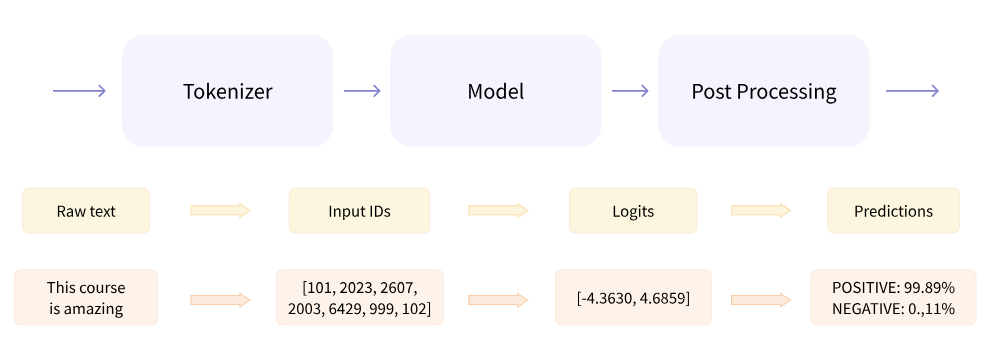

Q. **어떤 모델을 사용?**  
Helsinki-NLP team에서 만든 transformers 기반 **encoder-decoder** model인 **Marian NMT**를 사용.  
모델 주소: https://www.huggingface.co/Helsinki-NLP/opus-mt-ko-en

Q. **Tokenize?**  
긴 문장을 **Tokens(단어 또는 의미 있는 단위)**로 나누고,
컴퓨터가 이해할 수 있도록 숫자로 바꾸는 과정

Q. **Pretrained Tokenizer?**  
언어모델과 함께 훈련된 tokenizer.  
model이 기대하는 입력 형식으로 tokenizing을 수행함.   
예를 들어, 단어를 어떤 subword로 나눌지 (vocabulary를 어떻게 구성할지), 나눠진 token에 어떤 index를 매길지, 어떤 special token (ex. EOS, SOS ...) 등을 어떤 index를 매길지 등등


In [9]:
import torch
from transformers import MarianMTModel, MarianTokenizer

# Pretrained 모델과 토크나이저 로드 (한국어 -> 영어)
model_name = 'Helsinki-NLP/opus-mt-ko-en'

# pretrained tokenizer와 model을 불러오기
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# 입력 문장
input_text = "안녕하세요, 자연어 처리의 Transformer 모델을 실습해보겠습니다."

# tokenization -> model 통과 -> 후처리 (decode)
input_ids = tokenizer(input_text, return_tensors="pt").input_ids # 데이터 전처리 (text -> token)
print(input_ids)

outputs = model.generate(input_ids) # 모델 통과 (generation (enc -> dec))

translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True) # 데이터 후처리 (token -> text)
# skip special tokens? EOS, SOS 토큰 등 speical한 token은 사용자에게 보이지 않겠다는 뜻!

print("Input:", input_text)
print("Translated:", translated_text)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tensor([[ 4192,     3,  4787,   219,  6361,    53,  1220,  6221,    10,  1931,
           992,  9437, 32625,  2980,  5161, 40667,     2,     0]])
Input: 안녕하세요, 자연어 처리의 Transformer 모델을 실습해보겠습니다.
Translated: Hi, I'm going to run the Transformer model of natural language processing.


## Document Summarization

Q. **어떤 모델을 사용?**  
--> KoBART 기반 한국어 요약 모델을 사용 \
--> BART는 encoder-decoder(seq2seq) 구조의 생성 모델이며, 한국어 요약 데이터로 fine-tuning되어 긴 문서를 짧은 요약문으로 생성함

Q. **AutoTokenizer란?**  
--> Hugging Face Transformers library에서 제공하는 자동 tokenizer loader  
--> **지정한 모델에 맞는 tokenizer를 자동으로 불러와 텍스트를 토큰 단위로 변환함**

Q. **AutoModelForSeq2SeqLM란?**  
--> Encoder-Decoder 구조의 생성 모델을 자동으로 불러오는 loader \
--> 예: T5, BART, MarianMT 등과 같은 seq2seq 계열 모델을 불러올 때 사용함

모델 주소: https://huggingface.co/EbanLee/kobart-summary-v3

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "EbanLee/kobart-summary-v3"
tokenizer = ### Tokenizer 선언 (AutoTokenizer 사용) ###
model = ### model 선언 (AutoModelForSeq2SeqLM 사용) ###

text = """
삼성전자가 16일부터 이틀간 진행한 2026년형 TV와 오디오 신제품 체험행사 '삼성 AI TV 위크'가 마무리됐다고 19일 밝혔다.
일반 고객과 B2B 거래선 등 현장을 찾은 방문객들은 신제품 체험존에서 '마이크로 RGB', 'OLED' 등 프리미엄 TV 라인업부터 이동형 스크린 '무빙스타일', 라이프스타일 TV '더 프레임', 와이파이 스피커 '뮤직 스튜디오 5·7' 등 소비자 라이프스타일에 맞춰 다양하게 활용 가능한 삼성 TV 및 사운드 디바이스 신제품 라인업을 만나볼 수 있었다.
"""

inputs = ["summarize: " + text]

#### tokenizer() - Input data 전처리 ####
1.
#### model의 generate() - Input data 모델 통과 ####
#### argument로 min_length=10, max_length=100 추가 ####
2.
#### tokenizer.decode() - 최종 output 생성 ####
3.

print(summarized_text)

## Document Summarization (Answer)

In [10]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "EbanLee/kobart-summary-v3"
### Tokenizer 선언 (AutoTokenizer 사용) ###
tokenizer = AutoTokenizer.from_pretrained(model_name)
### model 선언 (AutoModelForSeq2SeqLM 사용) ###
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

text = """
삼성전자가 16일부터 이틀간 진행한 2026년형 TV와 오디오 신제품 체험행사 '삼성 AI TV 위크'가 마무리됐다고 19일 밝혔다.
일반 고객과 B2B 거래선 등 현장을 찾은 방문객들은 신제품 체험존에서 '마이크로 RGB', 'OLED' 등 프리미엄 TV 라인업부터 이동형 스크린 '무빙스타일', 라이프스타일 TV '더 프레임', 와이파이 스피커 '뮤직 스튜디오 5·7' 등 소비자 라이프스타일에 맞춰 다양하게 활용 가능한 삼성 TV 및 사운드 디바이스 신제품 라인업을 만나볼 수 있었다.
"""

inputs = ["summarize: " + text]

#### tokenizer() - Input data 전처리 ####
inputs = tokenizer(inputs, return_tensors="pt", padding=True, truncation=True)

#### model의 generate() - Input data 모델 통과 ####
#### argument로 min_length=10, max_length=100 추가 ####
outputs = model.generate(
    inputs["input_ids"],
    min_length=10,
    max_length=100
)
#### tokenizer.decode() - 최종 output 생성 ####
summarized_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(summarized_text)

config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

삼성 AI TV 위크는 삼성 TV 및 사운드 디바이스 신제품 체험행사로, 방문객들은 체험존에서 다양한 TV 라인업과 사운드 디바이스 신제품 라인업을 체험할 수 있었다.


# 2) BERT

## BERT Basic

### BERT Tokenizer
- Tokenize - 입력된 텍스트를 모델에서 처리할 수 있는 데이터로 변환하는 것
- BERT는 WordPiece tokenizing 방식을 사용  
ex1) "transformers" → ["transform", "##ers"]  
ex2) "unbelievable" → ["un", "##bel", "##iev", "##able"]

In [11]:
import pandas as pd
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") # Bert-base의 토크나이저

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
result = tokenizer.tokenize('Here is the sentence I want embeddings for.')
print(result)

['here', 'is', 'the', 'sentence', 'i', 'want', 'em', '##bed', '##ding', '##s', 'for', '.']


In [13]:
print(tokenizer.vocab['here'])

2182


In [14]:
# subword로 쪼개졌기 때문에 vocab에 없음. subword 별로 확인해보자!
print(tokenizer.vocab['embeddings'])

KeyError: 'embeddings'

In [15]:
print(tokenizer.vocab['em'])

7861


In [16]:
print(tokenizer.vocab['##bed'])

8270


In [17]:
print(tokenizer.vocab['##ding'])

4667


In [18]:
print(tokenizer.vocab['##s'])

2015


### Masked Language Modeling

In [19]:
from transformers import BertForMaskedLM
from transformers import AutoTokenizer

In [20]:
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
inputs = tokenizer('Samsung is [MASK] company.', return_tensors='pt')
outputs = model(**inputs)
# outputs = model(input_ids = inputs.input_ids, attention_mask = inputs.attention_mask)
# 와 동일
print(outputs)

MaskedLMOutput(loss=None, logits=tensor([[[ -6.4837,  -6.4430,  -6.4504,  ...,  -5.8114,  -5.5651,  -3.9347],
         [ -7.9329,  -7.7503,  -7.7910,  ...,  -7.1770,  -6.6556,  -4.9530],
         [-14.2886, -13.9899, -13.8590,  ..., -13.4473,  -8.7455, -10.7580],
         ...,
         [-13.9819, -14.0263, -14.0250,  ..., -12.9010, -10.3063,  -9.2195],
         [-15.1634, -14.5643, -14.9615,  ..., -11.5919, -12.1534,  -7.9676],
         [-14.8990, -14.7687, -14.8503,  ..., -13.8540, -12.5639,  -8.5897]]],
       grad_fn=<ViewBackward0>), hidden_states=None, attentions=None)


#### 정수 인코딩 결과
[PAD] - 0, [UNK] - 100, [CLS] - 101, [SEP] - 102, [MASK] - 103

In [22]:
print(inputs['input_ids']) # 정수 인코딩된 결과
print(tokenizer.decode(inputs['input_ids'][0])) # 다시 decoding 해보면?

tensor([[  101, 19102,  2003,   103,  2194,  1012,   102]])
[CLS] samsung is [MASK] company. [SEP]


#### Segment 인코딩 결과
- 입력이 두 문장이라면 두 번째 문장은 1의 값을 가집니다.

In [23]:
print(inputs['token_type_ids'])

tensor([[0, 0, 0, 0, 0, 0, 0]])


In [24]:
inputs = tokenizer('Samsung is [MASK] company.', 'I work at Samsung.', padding=True, return_tensors='pt')
print(inputs['token_type_ids'])

tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]])


#### Attention mask 결과
- \<PAD> 토큰이 아니라면 모두 1의 값을 가집니다.
- 즉, Attention mask란 학습되지 않는 \<PAD> 토큰을 구분하는 용도

In [25]:
print(inputs['attention_mask'])

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [26]:
inputs = tokenizer(['Samsung is [MASK] company.', 'I work at Samsung.'], padding=True, return_tensors='pt')
print(inputs['input_ids'])
print(inputs['attention_mask'])

tensor([[  101, 19102,  2003,   103,  2194,  1012,   102],
        [  101,  1045,  2147,  2012, 19102,  1012,   102]])
tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]])


#### [MASK] 토큰 예측  

In [27]:
from transformers import FillMaskPipeline
fill_mask = FillMaskPipeline(model=model, tokenizer=tokenizer)
# 문장의 [MASK] 위치에 올 가능한 단어를 예측해주는 pipeline

In [28]:
fill_mask('Samsung is a [MASK] company in korea.')

[{'score': 0.2192261964082718,
  'token': 12108,
  'token_str': 'telecommunications',
  'sequence': 'samsung is a telecommunications company in korea.'},
 {'score': 0.05982130020856857,
  'token': 20681,
  'token_str': 'semiconductor',
  'sequence': 'samsung is a semiconductor company in korea.'},
 {'score': 0.04741533100605011,
  'token': 7829,
  'token_str': 'shipping',
  'sequence': 'samsung is a shipping company in korea.'},
 {'score': 0.042927008122205734,
  'token': 20584,
  'token_str': 'multinational',
  'sequence': 'samsung is a multinational company in korea.'},
 {'score': 0.03434187173843384,
  'token': 2865,
  'token_str': 'media',
  'sequence': 'samsung is a media company in korea.'}]

- 정리 : BERT는 [MASK] Token을 예측하는 방식으로 학습되었다.

### Next Sentence Prediction

In [29]:
from transformers import BertForNextSentencePrediction
from transformers import AutoTokenizer
import torch
import torch.nn.functional as F

In [30]:
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForNextSentencePrediction LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
prompt = "I work at Samsung"
next_sentence = "Samsung is a good company in korea"

In [32]:
encoding = tokenizer(prompt, next_sentence, return_tensors='pt')

#### 정수 인코딩 결과
- [SEP] 102 토큰으로 문장을 구분

In [33]:
print(encoding['input_ids'])

tensor([[  101,  1045,  2147,  2012, 19102,   102, 19102,  2003,  1037,  2204,
          2194,  1999,  4420,   102]])


In [34]:
print(tokenizer.decode(encoding['input_ids'][0]))

[CLS] i work at samsung [SEP] samsung is a good company in korea [SEP]


#### Segment 인코딩 결과
- 0과 1을 통해, 문장 간의 segment를 구분해 주었다.


In [35]:
print(encoding['token_type_ids'])

tensor([[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]])


#### Next Sentence Prediction 실습

- BERT가 NextSentencePrediction 학습을 진행할 때, 두 문장이 이어지는 문장인지를 두고 IsNext와 IsNotNext 2개의 경우로 구분
- IsNext인 경우는 두 sentence pair의 label을 0으로 학습
- IsNotNext의 경우는 두 sentence pair의 label을 1로 학습

--> 즉, 0의 확률이 클수록 이어지는 문장이라고 판단내린 것

In [36]:
# 모델 출력 (logits) 얻기
logits = model(encoding['input_ids'], token_type_ids=encoding['token_type_ids']).logits

# 소프트맥스 확률 계산
probs = F.softmax(logits, dim=-1)

# 출력
labels = ['IsNext', 'NotNext']
for label, prob in zip(labels, probs[0]):
    percent = prob.item() * 100
    print(f"{label:8s}: {percent:.1f}%")

IsNext  : 100.0%
NotNext : 0.0%


- 만약 연관 없는 두 문장을 입력으로 준다면?

In [37]:
prompt = "Samsung is a good company in korea"
next_sentence = "I'm a student"

encoding = tokenizer(prompt, next_sentence, return_tensors='pt')
logits = model(encoding['input_ids'], token_type_ids=encoding['token_type_ids']).logits
probs = F.softmax(logits, dim=-1)

labels = ['IsNext', 'NotNext']
for label, prob in zip(labels, probs[0]):
    percent = prob.item() * 100
    print(f"{label:8s}: {percent:.1f}%")

IsNext  : 9.9%
NotNext : 90.1%


## BERT 이용 영화 리뷰 감성분석
- BERT를 실제 데이터를 통해 fine-tuning 해보기  
- fine-tuning 된 모델을 test 해보기

cf) Pandas & Numpy?
- Pandas: Table 형식의 데이터를 쉽게 다룰 수 있게 해주는 Python Library
- Numpy: 수치 계산을 빠르게 하기 위한 Python Library

In [38]:
import torch

from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np

### Naver 영화리뷰 감정분석 데이터 다운로드

In [39]:
!git clone https://github.com/e9t/nsmc.git

Cloning into 'nsmc'...
remote: Enumerating objects: 14763, done.
remote: Counting objects: 100% (14762/14762), done.
remote: Compressing objects: 100% (13012/13012), done.
remote: Total 14763 (delta 1748), reused 14762 (delta 1748), pack-reused 1 (from 1)
Receiving objects: 100% (14763/14763), 56.19 MiB | 18.76 MiB/s, done.
Resolving deltas: 100% (1748/1748), done.
Updating files: 100% (14737/14737), done.


### Pandas로 training data와 test data 로드

In [40]:
train = pd.read_csv("nsmc/ratings_train.txt", sep='\t')
test = pd.read_csv("nsmc/ratings_test.txt", sep='\t')

train = train[:1500]
test = test[:500]
train.head(15)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1


### document와 label 분리 (데이터 전처리)

In [41]:
train_document = [str(sentence) for sentence in train['document']]
train_label = [label for label in train['label']]
test_document = [str(sentence) for sentence in test['document']]
test_label = [label for label in test['label']]

print(train_document[:3])
print(train_label[:3])

['아 더빙.. 진짜 짜증나네요 목소리', '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', '너무재밓었다그래서보는것을추천한다']
[0, 1, 0]


### BERT Tokenizer를 사용하여 데이터 전처리

In [42]:
# BERT의 토크나이저로 문장을 토큰으로 분리
tokenizer = BertTokenizer.from_pretrained('distilbert/distilbert-base-multilingual-cased', do_lower_case=False)
train_tokens = tokenizer(train_document, padding=True, truncation=True, return_tensors="pt")
test_tokens = tokenizer(test_document, padding=True, truncation=True, return_tensors="pt")

# print(sentences[0])
print(train_tokens['input_ids'][0])
print(tokenizer.decode(train_tokens['input_ids'][0]))

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tensor([   101,   9519,   9074, 119005,    119,    119,   9708, 119235,   9715,
        119230,  16439,  77884,  48549,   9284,  22333,  12692,    102,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0, 

### Transformers의 Dataset, DataLoader 사용

In [43]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_tokens, train_label)
test_dataset = ReviewDataset(test_tokens, test_label)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model import (distilbert)

In [44]:
model = BertForSequenceClassification.from_pretrained('distilbert/distilbert-base-multilingual-cased', num_labels=2)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.trans

### 학습 전 성능 체크

In [45]:
correct_predictions = 0
total_predictions = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        #input_ids:     [101, 146, 1567, 1128, 0, 0]

        # huggingface tokenizer 사용 시, attention_mask 자동 생성
        attention_mask = batch['attention_mask'].to(device)
        #attention_mask:[  1,   1,    1,    1, 0, 0]

        # 예측해야 하는 정답 labels
        labels = batch['labels'].to(device)

        model = model.to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test accuracy before fine-tuning: {accuracy:.4f}")

/tmp/ipykernel_9009/3461785054.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Test accuracy before fine-tuning: 0.5240


In [46]:
from transformers import pipeline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nsmc_classifier = pipeline('sentiment-analysis',
                           model=model.cpu(), tokenizer=tokenizer, framework='pt')
id2label = {"LABEL_0": "negative", "LABEL_1": "positive"}

reviews= [
          "생각한 것보다는 영화가 재미없었어",
          "역시 재밌네ㅋㅋ 최고",
          "재밌긴한데, 재미없는 것 같기도 해"
]

results = nsmc_classifier(reviews)
for idx, result in enumerate(results):
    print(reviews[idx])
    for k, v in result.items():
        print(f" >> {k} : {id2label[v] if k == 'label' else v}")
    print()

# nsmc_classifier.save_pretrained('./pipeline')

생각한 것보다는 영화가 재미없었어
 >> label : positive
 >> score : 0.6143616437911987

역시 재밌네ㅋㅋ 최고
 >> label : positive
 >> score : 0.6043652892112732

재밌긴한데, 재미없는 것 같기도 해
 >> label : positive
 >> score : 0.5676466226577759



### Fine-tuning 진행

In [47]:
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 3
learning_rate = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
model.to(device) # GPU 사용이 가능한 경우

model.train()
for epoch in range(num_epochs):
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # optimizer 초기화
        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        # back propagation
        loss.backward()

        # model parameter update
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {average_loss:.4f}")

  0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_9009/3461785054.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch 1/3 - Average Loss: 0.7319


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch 2/3 - Average Loss: 0.6990


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch 3/3 - Average Loss: 0.6784


### Fine-tuning 후 Test

In [48]:
model.eval()
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test accuracy after fine-tuning: {accuracy:.4f}")

/tmp/ipykernel_9009/3461785054.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Test accuracy after fine-tuning: 0.5960


### Fine-tuning 모델 성능 확인

In [49]:
from transformers import pipeline

nsmc_classifier = pipeline('sentiment-analysis',
                           model=model.cpu(), tokenizer=tokenizer, framework='pt')

results = nsmc_classifier(reviews)
for idx, result in enumerate(results):
    print(reviews[idx])
    for k, v in result.items():
        print(f" >> {k} : {id2label[v] if k == 'label' else v}")
    print()

# nsmc_classifier.save_pretrained('./pipeline')

생각한 것보다는 영화가 재미없었어
 >> label : negative
 >> score : 0.589451014995575

역시 재밌네ㅋㅋ 최고
 >> label : positive
 >> score : 0.917047917842865

재밌긴한데, 재미없는 것 같기도 해
 >> label : negative
 >> score : 0.5754523277282715



### Fine-tuned model 사용하여 Sentiment Analysis pipline 구축
- sangrimlee/bert-base-multilingual-cased-nsmc
- 위 모델 명 사용하여 pipeline 구축
- 테스트 했던 리뷰 문장 테스트 해보기 (Inference)

모델 주소: https://www.huggingface.co/sangrimlee/bert-base-multilingual-cased-nsmc

In [50]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis", model="sangrimlee/bert-base-multilingual-cased-nsmc")

classifier("재밌긴한데, 재미없는 것 같기도 해")

config.json:   0%|          | 0.00/932 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/712M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sangrimlee/bert-base-multilingual-cased-nsmc
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'negative', 'score': 0.9637647271156311}]

## 한국어 감정 분석 실습 (다중 분류)

In [51]:
import torch

from transformers import BertTokenizer
from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

### 한국어 감정 분석 데이터 전처리

In [52]:
!git clone https://github.com/dongwxxkchoi/day2.git

Cloning into 'day2'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 11.04 MiB | 5.25 MiB/s, done.


In [53]:
data = pd.read_excel('./day2/data.xlsx') ## pd.read_json 이용

data=data.iloc[:,:2]
data.head(10)

,Sentence,Emotion
0,언니 동생으로 부르는게 맞는 일인가요..??,공포
1,그냥 내 느낌일뿐겠지?,공포
2,아직너무초기라서 그런거죠?,공포
3,유치원버스 사고 낫다던데,공포
4,근데 원래이런거맞나요,공포
5,남자친구가 떠날까봐요,공포
6,이거 했는데 허리가 아플수도 있나요? ;;,공포
7,내가불안해서꾸는걸까..,공포
8,일주일도 안 남았당...ㅠㅠ,공포
9,약은 최대한 안먹으려고 하는데좋은 음시있나요?0,공포


## 한국어 감정 분석 실습 (다중 분류) 정답

In [57]:
import torch

from transformers import BertTokenizer
from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import json
import pandas as pd
import numpy as np

data = pd.read_excel('./day2/data.xlsx') ## pd.read_json 이용

data=data.iloc[:,:2]
data.head(10)

data.loc[(data['Emotion'] == "공포"), 'Emotion'] = 0  #공포 => 0
data.loc[(data['Emotion'] == "놀람"), 'Emotion'] = 1  #놀람 => 1
data.loc[(data['Emotion'] == "분노"), 'Emotion'] = 2  #분노 => 2
data.loc[(data['Emotion'] == "슬픔"), 'Emotion'] = 3  #슬픔 => 3
data.loc[(data['Emotion'] == "중립"), 'Emotion'] = 4  #중립 => 4
data.loc[(data['Emotion'] == "행복"), 'Emotion'] = 5  #행복 => 5
data.loc[(data['Emotion'] == "혐오"), 'Emotion'] = 6  #혐오 => 6

data_sentence = [str(sentence) for sentence in data['Sentence']]
data_label = [label for label in data['Emotion']]

x_train, x_test, y_train, y_test = train_test_split(data_sentence, data_label, test_size=0.2, shuffle=True)
print(x_train[:10])
print(y_train[:10])

x_train = x_train[:1500]
y_train = y_train[:1500]
x_test = x_test[:500]
y_test = y_test[:500]

# BERT의 토크나이저로 문장을 토큰으로 분리
tokenizer = BertTokenizer.from_pretrained('klue/bert-base', do_lower_case=False)
train_tokens = tokenizer(x_train, padding=True, truncation=True, return_tensors="pt")
test_tokens = tokenizer(x_test, padding=True, truncation=True, return_tensors="pt")

# print(sentences[0])
print(train_tokens['input_ids'][0])
print(tokenizer.decode(train_tokens['input_ids'][0]))

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_tokens, y_train)
test_dataset = ReviewDataset(test_tokens, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = BertForSequenceClassification.from_pretrained('klue/bert-base', num_labels=7)

from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 3
learning_rate = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
model.to(device) # GPU 사용이 가능한 경우

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {average_loss:.4f}")

model.eval()
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test Accuracy: {accuracy:.4f}")

from transformers import pipeline

sentiment_classifier = pipeline('sentiment-analysis',
                           model=model.cpu(), tokenizer=tokenizer, framework='pt')
id2label = {
    "LABEL_0": "공포",
    "LABEL_1": "놀람",
    "LABEL_2": "분노",
    "LABEL_3": "슬픔",
    "LABEL_4": "중립",
    "LABEL_5": "행복",
    "LABEL_6": "혐오"
    }

sentence = ['나 너무 행복해']

result = sentiment_classifier(sentence)
print(result)

print(f"{id2label[result[0]['label']]}")

# sentiment_classifier.save_pretrained('./pipeline')

['둘째 만들러 가는듯', '개소리하고있네 진짜', '안양역에 내리면 수도군단으로 어떻게가나요??ㅠㅠ', ' 돈있으면 성형했죠..', '추운게 더 좋아..', '니들 나라로 꺼져라', '리얼 기대기대 믿고 봅니다 ♡', '잘하건 못하건 그냥 팀에 여자있으면 흥분하는 애들 쫌 있더라 ㅋ', '미국은들 다 쿨한줄알았더만 우리나라 저번 대선 끝나고 문재인이랑 하는짓이 똑같네', '낮짝보기 싫지만.생중계 해라! 욕이라도 끌어 붓자!']
[5, 2, 0, 3, 4, 3, 5, 4, 1, 2]


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Epoch 1/3 - Average Loss: 1.7741


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2/3 - Average Loss: 1.3485


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3/3 - Average Loss: 1.0296
Test Accuracy: 0.5160
[{'label': 'LABEL_5', 'score': 0.6248904466629028}]
행복


## BERT 기반 한국어 감정 분류모델 (pipeline 이용)
- hun3359/klue-bert-base-sentiment
- 위 모델 명 사용하여 pipeline 구축 (단 2줄)
- Inference 해보기

모델 주소: https://huggingface.co/hun3359/klue-bert-base-sentiment

In [58]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="hun3359/klue-bert-base-sentiment")

classifier("오늘 밥이 너무 맛있었어. 행복해")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: hun3359/klue-bert-base-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[{'label': '만족스러운', 'score': 0.38918793201446533}]

# 3) GPT-2

## 텍스트 생성해보기

In [59]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

In [61]:
# 토크나이저 및 모델 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# 텍스트 생성 파이프라인 설정
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)
# generator = pipeline("text-generation", model="gpt2") # 이것도 가능. tokenizer 자동 호출

# 텍스트 생성 예제
prompt = "Once upon a time in a faraway land"
generated_text = generator(prompt, max_length=100, num_return_sequences=1)

print("\n\nGenerated Text:")
print(generated_text[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Generated Text:
Once upon a time in a faraway land, the ancient gods were in the midst of the battle. The Greeks, as they are known, were a powerful people, and their people were the most powerful of all. They were the most powerful people in the land, and they could do nothing to aid the Greeks except seek to win over the people of Asia to their cause.

But now, this time, the gods have come and taken over the land and will take it over again. And it is their victory that will bring about the great calamity and ruin of the land, that will make all the peoples of the world tremble.

I remember that when I was a boy growing up in the same family, my parents would be in the middle of the street screaming "Ecclesiastes!" They were so angry. They would say, "Ecclesiastes, what are you doing?!" They would say, "Ecclesiastes, we have to go to the streets." I would look at them and I would ask, "Oh, what are you doing, what are you doing?" They would say, "Ecclesiastes, we are not going to 

## GPT-2로 챗봇 만들어보기

In [62]:
from transformers import pipeline

In [64]:
# 토크나이저 및 모델 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# 텍스트 생성 파이프라인 설정
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    pad_token_id=tokenizer.eos_token_id, # 활성화
    # gpt-2 같은 경우는, tokenizer가 padding token 정의 x.
    # 문서의 sentences를 이어 붙여서, padding 없이 eos_token 만으로 구분해 같은 크기로 나눴기 때문.
    # 하지만, batch 단위 생성 시 padding 필요하므로 eos token으로 별도로 지정해주기
)

def chat_with_gpt2(user_input):
    response = generator(user_input, max_new_tokens=100, num_return_sequences=1)
    full_text = response[0]['generated_text']
    generated_part = full_text[len(user_input):].strip()
    return generated_part

# 예시 대화
conversation = True
print("Let's talk to GPT-2! If do you want to stop to talk, input the word, 'Stop'")

while conversation == True:
  user_input = input('You: ')
  if user_input == 'Stop' or user_input == 'stop':
    conversation = False
  else:
    print('GPT-2: ', chat_with_gpt2(user_input))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Let's talk to GPT-2! If do you want to stop to talk, input the word, 'Stop'
You: hello i'm Hyejun. Nice to meet you


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-2:  .

I'll be waiting for you at the door.

Good morning.

I'm going to eat a bowl of rice and you two.

Are you good?

Okay.

I'm going to eat you breakfast.

I like the way you look at me.

I like your hair.

I like your blue eyes.

I like your red lips.

I like your blue hair.

I like your
You: stop


* 좀더 chatbot과 유사하게 만들어보기
* 현재 대화 데이터를 chat-history에 유지하는 챗봇

In [65]:
# example
chat_history = [
    "User: Hello!",
    "Bot: Hi there! How can I assist you today?",
    "User: What is the weather like in Seoul?",
    "Bot: I’m not connected to real-time data, but typically in June, Seoul is warm and humid with occasional rain.",
    "User: Thanks! Can you tell me a joke?",
    "Bot: Sure! Why don’t scientists trust atoms? Because they make up everything.",
    "User: Haha! What's the capital of France?",
    "Bot: The capital of France is Paris.",
    "User: How do I cook pasta?",
    "Bot: First, bring a pot of water to a boil, add salt, then add your pasta. Cook for 8–10 minutes, stirring occasionally, then drain and serve."
]

In [66]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

# 모델 및 토크나이저 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# pipeline 생성
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 대화 이력 초기화
chat_history = []

def chat_with_gpt2(user_input):
    global chat_history

    # 1. 사용자 입력 추가
    chat_history.append(f"User: {user_input}")

    # 2. 전체 히스토리를 하나의 prompt로 구성
    prompt = "\n".join(chat_history) + "\nBot:"

    # 3. 모델을 사용하여 응답 생성
    response = generator(
        prompt,
        max_new_tokens=50,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
    )

    # 4. 응답 텍스트 파싱
    generated_text = response[0]['generated_text']
    bot_reply = generated_text[len(prompt):].strip().split("\n")[0]  # 첫 줄만 추출

    # 5. 봇 응답 저장
    chat_history.append(f"Bot: {bot_reply}")

    return bot_reply, chat_history

# 예시 대화 루프
print("Let's talk to GPT-2! If you want to stop, type 'Stop'")

while True:
    user_input = input("User: ")
    if user_input.lower() == "stop":
        break
    bot_reply, _ = chat_with_gpt2(user_input)
    print(f"Bot: {bot_reply}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Let's talk to GPT-2! If you want to stop, type 'Stop'
User: Hi! My name is Hyejun. Nice to meet you!


Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: Yes, I have a question. I am a Korean player. Will you be able to confirm my name?
User: What is my name?


Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: "Jin" (리게), or "Jin-e". I am 17 years old and currently playing for Team Liquid.
User: stop


In [67]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

# 모델 및 토크나이저 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# pipeline 생성
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 대화 이력 초기화
chat_history = []

def chat_with_gpt2(user_input):
    global chat_history

    # 1. 사용자 입력 추가
    chat_history.append(f"User: {user_input}")

    # 2. 전체 히스토리를 하나의 prompt로 구성
    prompt = "\n".join(chat_history) + "\nBot:"

    # 3. 모델을 사용하여 응답 생성
    response = generator(
        prompt,
        max_new_tokens=50,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,           # 추가> 다양성 확보!
        top_k=50,                 # 추가> 상위 50개 후보 중 샘플링!
        temperature=0.8           # 추가> 창의성 조절!
        # what's these???????
    )

    # 4. 응답 텍스트 파싱
    generated_text = response[0]['generated_text']
    bot_reply = generated_text[len(prompt):].strip().split("\n")[0]  # 첫 줄만 추출

    # 5. 봇 응답 저장
    chat_history.append(f"Bot: {bot_reply}")

    return bot_reply, chat_history

# 예시 대화 루프
print("Let's talk to GPT-2! If you want to stop, type 'Stop'")

while True:
    user_input = input("User: ")
    if user_input.lower() == "stop":
        break
    bot_reply, _ = chat_with_gpt2(user_input)
    print(f"Bot: {bot_reply}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Let's talk to GPT-2! If you want to stop, type 'Stop'
User: Hi! what is the weather in Seoul today?


Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'num_return_sequences', 'pad_token_id', 'top_k', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: So that's cool. My phone is a small phone with a 6.1 mhz display (it has the same resolution as my phone) and I am using Skype, so it's probably sunny out here. My phone is 2.7 m
User: stop


## Decoding Strategy 점검

### a) 결정적 / Search Based

In [68]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [69]:
prompt = "I enjoy walking with my cute dog"

input_ids = tokenizer.encode(prompt, return_tensors='pt')

greedy_output = model.generate(input_ids,
                               max_length=50)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll


In [70]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5, # num_beams = 5로 설정해 5개의 후보를 유지하도록 함
    early_stopping=True # 만약 후보 중 하나가 생성이 끝났고, 가장 높은 확률을 갖는다면 그걸 선택하기
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again. I'm not sure if I'll


In [71]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5,
    no_repeat_ngram_size=2, # 반복 방지 parameter
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to take a break


In [72]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5,
    repetition_penalty=1.5, # 반복 방지 parameter
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I don't think I'll ever be able to walk with her again."

"You're right," she said. "It's not like I'm going to be able to walk with her again


*   한국어로 해보기




In [73]:
from transformers import GPT2LMHeadModel
model = GPT2LMHeadModel.from_pretrained(
    "skt/kogpt2-base-v2",
)
model.eval()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)

In [74]:
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    eos_token="</s>",
)

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [75]:
input_ids = tokenizer.encode("안녕하세요", return_tensors="pt")

In [76]:
import torch

# greedy search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
    )

print('Greedy search: ', tokenizer.decode([el.item() for el in generated_ids[0]]))

Greedy search:  안녕하세요?"
"그럼, 그건 뭐예요?"
"그럼, 그건 뭐예요?"
"그럼, 그건 뭐예요?"
"그럼, 그건 뭐예요?"



In [77]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

안녕하세요?"
"그렇지 않습니다."
"그렇지 않습니다."
"그렇지 않습니다."
"그렇지 않습니다."
"그렇지 않습니다."
"그렇지 않습니다."
"그


- N-gram penalty를 적용해 본다면?

In [78]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
        no_repeat_ngram_size=2,
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

안녕하세요?"
"그렇지 않습니다."
그녀는 고개를 끄덕였다.
"아무튼, 그건 그렇고."
"그래, 그래. 그게 무슨 말인지 알겠어."
그녀의 눈에서 눈물이 흘러내


- Token-based penalty를 적용해 본다면?

In [79]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
        repetition_penalty=2.0
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

안녕하세요?"
"그렇지 않습니다."
"아니오. 그게 무슨 말씀이십니까?"
"당신은 당신을 사랑하고 있습니까?"
"그렇지 않습니다. 당신은 당신을 사랑하고


### b) 확률적 / Sampling Based

In [80]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [81]:
prompt = "Once upon a time"

input_ids = tokenizer.encode(prompt, return_tensors='pt')
greedy_output = model.generate(input_ids, max_length=50)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a


In [82]:
output_1 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=0.5
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_1[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time, the only way to be truly good is to be smart. He did that.

He had done that before.

He had done that before.

He had done that before.

He had done


In [83]:
output_2 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=1.5
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_2[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time, during or immediately before the occurrence, a character must speak a long, high declamatory declimatory (often to a child who cannot understand the term). On each of the "before" or when "just" or


In [84]:
output_3 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_k=50
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_3[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time my character, that of the hero, has taken off and landed on a dangerous island.

The island, made up of small islands like the one I represent in the story, is named the Island of the Living Dead,


In [85]:
output_4 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_p=0.9
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_4[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time, my parents were very close to my father and they taught him to work, go to school, and get married. I remember when I was growing up, he would visit the house in my neighborhood and look at the window.


In [86]:
output_5 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_k=40,
    top_p=0.9,
    temperature=1.0
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_5[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
Once upon a time when the Earth was still a small, faraway place, it seems that some of the human race had taken refuge here.

But with the recent outbreak of war on Mars, the only way out of this predicament was to


### 각 상황에 알맞은 Decoding Strategy 찾아보기 (실습)
- 지금까지 배운 다양한 전략들을 사용해, 각 경우에 **가장 잘 맞는 strategy를 결정해보기**

#### cf) parameter 정리

1. 출력 길이 제어
- max_length: 생성될 시퀀스의 최대 길이
- min_length: 최소 생성 길이. 이보다 짧으면 eos_token을 무시함
- early_stopping: True이면 eos_token이 생성되면 바로 중단

2. Search 기반 전략
- num_beams: Beam search를 위한 beam 개수 설정
- num_return_sequences: 몇 개의 결과를 출력할지 (beam search 시 여러 개 받을 수 있음)
- length_penalty: 짧은 문장을 불이익, 긴 문장을 선호하는 정도 조절 (1.0: 기본)
- early_stopping: True이면 beam search 중 eos_token 등장 시 바로 종료

3. 반복 제어 전략
- no_repeat_ngram_size: 같은 n-gram 반복 금지
- repetition_penalty: 반복되는 토큰에 페널티 부여

4. Sampling 기반 전략
- do_sample: Sampling 전략 사용 여부 (True 시 아래 옵션들과 함께 사용됨)
- temperature: 확률 분포 조절 (높을 수록 다양성 증가)
- top_k: 상위 k개의 token만 sampling 후보로 사용
- top_p: 누적 확률 p 까지의 토큰들만 sampling 후보로 사용




모델 주소: https://huggingface.co/skt/kogpt2-base-v2

In [87]:
import torch
from transformers import GPT2LMHeadModel
from transformers import PreTrainedTokenizerFast

model = GPT2LMHeadModel.from_pretrained(
    "skt/kogpt2-base-v2",
)

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token='</s>', eos_token='</s>', unk_token='<unk>', pad_token='<pad>', mask_token='<mask>'
)

model.eval()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)

- 창의적인 대답이 필요한 경우?
- 안정적인 대답이 필요한 경우?
- 반복 제어가 필요한 경우?  
각 경우로 분류해보고 알맞은 decoding strategy를 사용해보자

In [88]:
prompt = "미래에는 인간과 인공지능이 함께"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

미래에는 인간과 인공지능이 함께 할수 있다는 것을 보여주는 것이 목표”라며 “이를 기반으로 한 미래기술인 인재가 양성의 선순환을 만들어낼 수 있도록 하겠다”고 말했다.
박성민 SK텔레콤 기술원장은 “어려


In [89]:
prompt = "삶의 의미는 무엇일까?"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

삶의 의미는 무엇일까?"
나는 이렇게 되묻는다.
"여러분은 여러분의 삶의 가치를 한 단계 더 높이 보려고 노력하는 분, 한 단계 더 높여보고자 하는 분, 한단계 더 올려보고자 하는 분이시죠."
그것은 아주


In [90]:
prompt = "지구는 태양으로부터"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

지구는 태양으로부터 30억광년 떨어져 있어 태양이 거의 없어 태양빛을 가장 많이 흡수한다.
태양과 가장 가까운 지역에서 발견되는 태양은 그 크기 또한 엄청나기 때문에 태양의 빛을 가장 많이 흡수해 내는 곳이다.
태양은 태양빛을 흡수하기도 하지만 태양의 에너지를


In [91]:
prompt = "광합성은 식물이 빛을 이용하여"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

광합성은 식물이 빛을 이용하여 광합성을 하면 자연 광합성 효과를 얻어 광합성 작용을 해 이산화탄소 배출과 탄소 배출을 줄일 수 있다.
탄소 포집 방법은 태양광발전 시설의 효율을 높이기 위해 필요한 기초연구용 원자로에서 추출하는 원자로, 태양광발전소를 사용하면 효율


In [92]:
prompt = "경제 인플레이션이 발생하는 이유는"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

경제 인플레이션이 발생하는 이유는 미국 경제가 안정되고 달러 가치가 절상되지 않기 때문이라고 밝혔다.
유로화는 영국의 경제성장률도 올해 2.5%에서 내년에 1.3%로 낮아지는 등 올해 3% 성장에 그치고 내년에는 5%를 밑돌 것으로 예상됐다.
국제


In [93]:
prompt = "기술은 빠르게 변화하고 있다. 기술은 우리의 일상생활에 영향을 미친다. 기술은 계속해서"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

기술은 빠르게 변화하고 있다. 기술은 우리의 일상생활에 영향을 미친다. 기술은 계속해서 발전할 것이고 사람들의 라이프스타일이 변화한다. 기술이 발전하는 속도는 우리가 더 빠르고 안전하게 사용할 수 있는 수준으로 변화할 것이다. 우리의 삶에는 여러 가지 변화가 있다"고 말했다.
미국 경제전문잡지인 CN


# 4) BERT vs GPT-2

## Sentimental Analysis

- Sentimental Analysis dataset으로 BERT test
- SST-2 (Stanford Sentiment Treebank 2)는 Stanford NLP Group에서 만든 대표적인 감성 분석(Sentiment Analysis) 데이터셋

In [94]:
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader

# SST-2 데이터셋 로드
dataset = load_dataset("glue", "sst2")

# 데이터셋의 일부분만 사용 (속도 향상을 위해)
small_test_dataset = dataset['validation'].shuffle(seed=42).select(range(500))

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [95]:
class SST2Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [96]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from tqdm import tqdm

# BERT 토크나이저 및 모델 로드
bert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

# 모델 평가 모드로 설정
bert_model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [98]:
# 데이터 전처리
texts = list(small_test_dataset['sentence'])
labels = list(small_test_dataset['label'])

encodings = bert_tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# sst 데이터셋 인스턴스 생성
test_dataset_bert = SST2Dataset(encodings, labels)

# DataLoader 설정
test_loader_bert = DataLoader(test_dataset_bert, batch_size=32, shuffle=False)

In [99]:
# 예측 수행
correct = 0
total = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for _, batch in tqdm(enumerate(test_loader_bert)):
        inputs = {key: val for key, val in batch.items() if key != 'labels'}
        labels = batch['labels']
        outputs = bert_model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

bert_accuracy = correct / total
print(f"BERT Accuracy: {bert_accuracy:.2f}")

0it [00:00, ?it/s]/tmp/ipykernel_9009/3096280086.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
16it [00:24,  1.52s/it]

BERT Accuracy: 0.91


In [102]:
sample_text = "This movie was surprisingly good."

inputs = bert_tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = bert_model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    probs = torch.softmax(outputs.logits, dim=-1)

label_map = {0: "negative", 1: "positive"}

print("Text:", sample_text)
print("Prediction:", label_map[prediction])
print("Probabilities:", probs)

Text: This movie was surprisingly good.
Prediction: positive
Probabilities: tensor([[1.4912e-04, 9.9985e-01]])


- GPT-2도 같은 task로 test 해보자

모델 주소: https://www.huggingface.co/michelecafagna26/gpt2-medium-finetuned-sst2-sentiment

In [103]:
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification

# GPT-2 토크나이저 및 모델 로드
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('michelecafagna26/gpt2-medium-finetuned-sst2-sentiment')
gpt2_model = GPT2ForSequenceClassification.from_pretrained('michelecafagna26/gpt2-medium-finetuned-sst2-sentiment', num_labels=2)

# GPT-2는 디폴트로 패딩 토큰이 없으므로 설정
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# 모델 평가 모드로 설정
gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id
gpt2_model.eval()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: michelecafagna26/gpt2-medium-finetuned-sst2-sentiment
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=1024, out_features=2, bias=False)
)

GPT 계열 모델을 classification으로 사용할 땐, 마지막 hidden state를 사용함. (full context를 담고 있기 때문에)  
해당 state에 classification head 달기.

In [105]:
# 데이터 전처리
texts = texts = [str(x) for x in small_test_dataset['sentence']]
labels = small_test_dataset['label']
encodings = gpt2_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
attention_mask = encodings.attention_mask
encodings['attention_mask'] = attention_mask

# sst 데이터셋 인스턴스 생성
test_dataset_gpt2 = SST2Dataset(encodings, labels)

# DataLoader 설정
test_loader_gpt2 = DataLoader(test_dataset_gpt2, batch_size=32, shuffle=False)

In [106]:
# 예측 수행
correct = 0
total = 0
correct_predictions = 0
total_predictions = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for _, batch in tqdm(enumerate(test_loader_gpt2)):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        outputs = gpt2_model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

gpt_accuracy = correct_predictions / total_predictions
print(f"GPT Accuracy: {gpt_accuracy:.2f}")

0it [00:00, ?it/s]/tmp/ipykernel_9009/3096280086.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
16it [03:17, 12.35s/it]

GPT Accuracy: 0.91


In [107]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')
classifier("I've been waiting for a HuggingFace course my whole life.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9598046541213989}]

In [108]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model='michelecafagna26/gpt2-medium-finetuned-sst2-sentiment')
classifier("I've been waiting for a HuggingFace course my whole life.")
# negative LABEL_0

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: michelecafagna26/gpt2-medium-finetuned-sst2-sentiment
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'POSITIVE', 'score': 0.896836519241333}]

여러 문장 직접 테스트해보자

## Question - Answering

* BERT로 QA (beomi/kcbert-base)

In [113]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, QuestionAnsweringPipeline
import tensorflow as tf
import tqdm.notebook
import math

model_name = "monologg/koelectra-base-v3-finetuned-korquad"

model = AutoModelForQuestionAnswering.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

qa = pipeline("question-answering", model=model, tokenizer=tokenizer)

context = "윤여정은 1966년 연극 배우로 연기 경력을 시작하였고, 2021년 영화 '미나리'의 순자 역으로 아카데미 여우조연상을 수상했다."

question1 = '윤여정의 직업은?'
question2 = '윤여정은 2021년 무엇을 했나?'
question3 = '윤여정의 미나리에서의 역할은?'

print(qa(question=question1, context=context))
print(qa(question=question2, context=context))
print(qa(question=question3, context=context))

config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/449M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForQuestionAnswering LOAD REPORT from: monologg/koelectra-base-v3-finetuned-korquad
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

{'score': 0.9999961230751069, 'start': 11, 'end': 17, 'answer': '연극 배우로'}
{'score': 0.5201579781714827, 'start': 55, 'end': 66, 'answer': '아카데미 여우조연상을'}
{'score': 0.9996583873257805, 'start': 48, 'end': 50, 'answer': '순자'}


* GPT-2로 QA

In [125]:
import torch
from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast

# KoGPT-2 모델과 토크나이저 로드 (질문 답변용)
model_name = 'skt/kogpt2-base-v2'
kogpt2_model = GPT2LMHeadModel.from_pretrained(model_name)
kogpt2_tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)

# 질문에 대한 답변 생성 함수 (KoGPT-2)
def generate_answer_kogpt2(context, question):
    input_text = f"문맥: {context}\n질문: {question}\n답변:"
    input_ids = kogpt2_tokenizer.encode(input_text, return_tensors='pt')

    outputs = kogpt2_model.generate(input_ids, max_length=150, num_return_sequences=1, no_repeat_ngram_size=2, top_p=0.95, top_k=50)
    answer = kogpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # "답변:" 이후의 텍스트만 추출
    answer = answer.split("답변:")[1].strip()

    return answer

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [126]:
generate_answer_kogpt2(context, question1)

'배우로서 윤 여정의 역할은?\n질문자: 영화배우로서윤여정이 배우로서의 윤여를 맡은 이유는?\n윤 여정은 배우로써 윤여의 역할을 맡은 이유?\n질의문자 : 배우로서, 윤여는 배우가 되기 위해 배우를 선택했다고 한다.\n질문자로 답변하자면, 윤여(윤여의 역할)는 배우의 직업으로 배우에 대한 선택권을 가진다고 한다.\n윤여(배우로서의윤여는 윤의 역할) 윤(윤의) 역할은 배우에게 배우 선택권이 있는 것이다.\n질문의 답변은 윤이 배우와 배우 사이의 관계에 대해 질문하는 것이다.'

In [127]:
generate_answer_kogpt2(context, question2)

'"그동안 제가 했던 말들을 다 기억하고 있다"\n질문자: “제가 했던 말을 다 기억한다”\n답문자: “그동안 제게 했던 말이 다 잊혀졌다”\n문항: “이제 제 말을 기억해요. 제 말들이 다 잊어버렸어요. 제가 제 말에 대해 기억하지 못해서요. 저는 제 말이 기억나지 않아요. 기억이 안 나요. 그건 제가 기억을 못 하는 거예요. 하지만 제 말은 기억할 수 있어요."\n질문자로 답변하는 윤 여정은, “'

In [128]:
generate_answer_kogpt2(context, question3)

'미나리는 윤이형이 연기한 미나의 모습과는 다른 모습이었다.\n질문자: 질문자 : 윤은형이 미나를 연기할 때 미나는 미나가 아닌 미나와 같은 모습이었다고 한다.\n질문자로 답변하자면 미나, 미나에 대한 기억이 전혀 없는 상태였다고 한다.\n답답: 이게 무슨 소리야? 미나라는 미남인데 미남이냐고?\n질문으로 답하자면, 미라는 미남에 대한 추억이 없는 상태였다.\n질문에서 질문자가 미남을 연기하는 동안 미남은 미남의 모습을 그대로 유지한 채'

# 5) 간단한 Retrieval test

### 최근 BERT 계열 모델들은 어떻게 쓰이고 있는가?  
- RAG (Retrieval Augmented Generation) system의 시스템의 핵심 Retrieval backbone으로 쓰임
- Retrieval란 대규모 문서 집합으로부터 질문과 관련 있는 문서나 문장을 찾아내는 과정을 의미함
- BERT 계열의 모델들은 **문서를 의미적으로 인코딩**해, 벡터 공간에서 **유사도를 기반으로 관련 정보를 검색**함
- 이렇게 검색된 문서는 GPT 등의 생성 모델이 보다 정확하고 풍부한 응답을 생성하는 데에 필요한 context로 제공됨


In [118]:
import torch
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F

# 문서 리스트
documents = [
    "삼성 라이온즈는 강민호 선수를 포함해 6개의 포지션에서 올스타 투표 1위를 기록하고 있다.",
    "LG 트윈스는 2023 시즌에 이어 다시 한 번 우승에 도전하고 있다.",
    "SSG 랜더스의 최정 선수가 올 시즌 500 홈런을 기록했다.",
    "한화 이글스는 탄탄한 마운드를 바탕으로 1위 자리 탈환을 노리고 있다.",
    "롯데 자이언츠는 레이예스 선수를 필두로 폭발적인 방망이를 자랑하고 있다.",
]

In [119]:
# 1. 문서 인코딩 (with BERT)
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

def embed(text):
    inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1)  # naive하게 mean pooling 사용

doc_embeddings = torch.stack([embed(doc)[0] for doc in documents])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [120]:
# 2. 유저 질문
question = "삼성 라이온즈와 관련된 뉴스가 있니?"

# 3. 질문 인코딩 후 문서들과 유사도 비교
q_embedding = embed(question)  # (1, hidden)
sims = F.cosine_similarity(q_embedding, doc_embeddings)
top_doc = documents[sims.argmax()]

print(f"Retrieved Document:\n{top_doc}")

Retrieved Document:
삼성 라이온즈는 강민호 선수를 포함해 6개의 포지션에서 올스타 투표 1위를 기록하고 있다.


- 이처럼 GPT를 필두로 한 생성형(Generative) 모델이 주류를 이루고 있지만, BERT와 같은 이해 기반(Understanding) 모델 역시 여전히 정보 검색, 의미 파악 등의 측면에서 중요한 역할을 수행하고 있음
